In [1]:
import sys
sys.path.append("..")

from pathlib import Path

import calendar
import datetime as dt

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from ros_database.processing.surface import load_station_metadata
from src.plotting import plot_climatology

DATAPATH = Path("../data") / "climatological_winter_period_by_station.csv"

# Cartopy projection for NSIDC North Polar Stereographic
map_projection = ccrs.Stereographic(central_latitude=90, central_longitude=-45, true_scale_latitude=70)

## Read station metadata

In [2]:
station = load_station_metadata()

## Read data and calculate statistics

In [3]:
por = pd.read_csv(DATAPATH, index_col=0, parse_dates=True)

# t2m_begin,t2m_end is not converted to datetime automatically
por["t2m_begin"] = pd.to_datetime(por["t2m_begin"])
por["t2m_end"] = pd.to_datetime(por["t2m_end"])
por["t2m_duration"] = (por["t2m_end"] - por["t2m_begin"])
por["winter_length"] = (365-por.first_day) + por.last_day
por.sort_values(by="t2m_duration", ascending=False)

por.head()

/tmp/ipykernel_951585/89518135.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  por = pd.read_csv(DATAPATH, index_col=0, parse_dates=True)


,t2m_begin,t2m_end,t2m_nvalid_pc},ptype_begin,ptype_end,ptype_nvalid_pc},sog_begin,sog_end,sog_nvalid_pc},first_day,last_day,t2m_duration,winter_length
BGAA,2001-07-21,2014-07-24,30.387205,2002-02-21,2014-07-21,22.011469,NaN,NaN,0.000000,294,142,4751 days,213
BGBW,1941-07-22,2023-11-13,82.620988,2002-01-24,2023-11-09,29.560302,2004-02-25,2023-11-13,99.736184,295,105,30064 days,175
BGCO,1986-05-10,2014-07-24,82.315830,2002-02-21,2014-07-18,10.306776,2004-02-25,2014-07-24,99.658165,265,145,10302 days,245
BGGH,2001-07-21,2023-11-13,60.017176,2001-09-12,2023-11-09,43.859649,NaN,NaN,0.000000,292,117,8150 days,190
BGJN,2001-07-21,2023-11-13,59.845418,2001-09-12,2023-11-11,36.598320,NaN,NaN,0.000000,275,133,8150 days,223


There are 222 (out of 244) stations that end after 2022-12-31

In [4]:
por = por[por["t2m_end"] > "2022-12-31"]
len(por)

222

Of those stations with records that end after 2022-12-31, there are 145 stations that begin on or befor 1979-01-01

In [5]:
por[por["t2m_begin"] < "1979-01-01"]

,t2m_begin,t2m_end,t2m_nvalid_pc},ptype_begin,ptype_end,ptype_nvalid_pc},sog_begin,sog_end,sog_nvalid_pc},first_day,last_day,t2m_duration,winter_length
BGBW,1941-07-22,2023-11-13,82.620988,2002-01-24,2023-11-09,29.560302,2004-02-25,2023-11-13,99.736184,295,105,30064 days,175
BGKK,1943-10-09,2023-11-13,51.216844,2001-07-21,2023-11-13,38.755981,2004-02-25,2023-11-13,99.736184,288,129,29255 days,206
BGSF,1941-12-01,2023-11-13,96.161427,2001-10-06,2023-11-10,29.376781,2004-02-25,2023-11-13,99.736184,272,126,29932 days,219
BGTL,1951-09-01,2023-11-11,97.095184,2001-07-21,2023-11-11,31.034483,2004-08-16,2004-08-16,100.000000,253,154,26369 days,266
BIAR,1931-01-03,2023-11-12,72.757025,2002-02-21,2023-11-09,43.822491,2004-02-25,2023-11-12,99.736148,336,48,33916 days,77
...,...,...,...,...,...,...,...,...,...,...,...,...,...
ULPB,1932-01-01,2023-11-12,79.540442,2010-12-29,2023-11-12,31.178222,2004-02-25,2023-11-12,99.736148,310,94,33553 days,149
USHH,1932-01-01,2023-11-13,86.776933,2010-08-19,2023-11-12,65.970211,2004-02-25,2023-11-13,99.736184,289,104,33554 days,180
USNN,1969-01-01,2023-11-13,76.911178,2001-07-21,2023-11-12,44.503067,2004-02-25,2023-11-13,99.736184,288,110,20039 days,187
USRR,1932-01-01,2023-11-13,80.414245,2001-07-21,2023-11-13,42.375169,2004-02-25,2023-11-13,99.736184,288,112,33554 days,189


## Determine set of long-term stations

I am looking for stations with periods of record that start on or before 1979-01-01 and have sufficient valid 2 m temperature data.

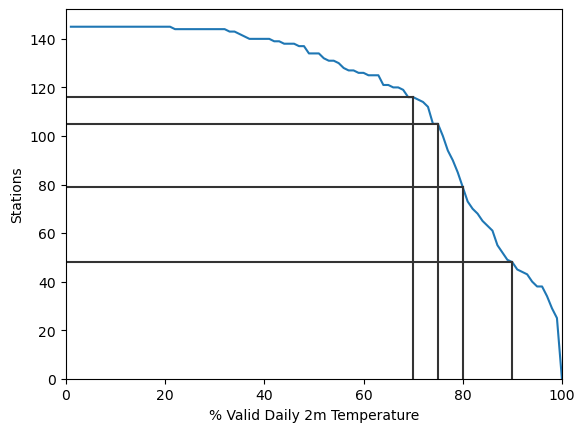

In [6]:
percentile = np.arange(1,101,1)
nstation = pd.Series([((por["t2m_begin"] <= "1979-01-01") & 
                       (por["t2m_nvalid_pc}"] > pc)).sum() for pc in percentile],
                     index=percentile)

fig, ax = plt.subplots()

nstation.plot(ax=ax)
ax.set_xlabel("% Valid Daily 2m Temperature")
ax.set_xlim(0,100)

ax.set_ylabel("Stations")
ax.set_ylim(0,)

def data2axis(x, y):
    """Transforms from data to axis for use with
    axhline and axvline
    """
    return ax.transAxes.inverted().transform(ax.transData.transform((x, y)))

for pc in [70, 75, 80, 90]:
    p, n = pc, nstation.loc[pc]
    xmax, ymax = data2axis(p, n)
    ax.axvline(p, ymax=ymax, c='0.2')
    ax.axhline(n, xmax=xmax, c='0.2')


We select 70% as the threshold for the required number of valid daily temperature records.

In [7]:
is_long_term_record = (por["t2m_begin"] <= "1979-01-01") & (por["t2m_nvalid_pc}"] > 70)

We create two `DataFrames`; one containing long-term stations and one containing the rest of the stations in the database.

_A better way to select usable long-term stations would be to evaluate station records by the number of valid daily records in each month and then select years with a complete set of months.  I'm not sure how this would play into determining annual start and end of the winter period_ 

_For the paper generate a table listing valid stations.  This could be in the paper repo._

In [8]:
lt_station = station.join(por[is_long_term_record], how="inner")
other_station = station.join(por[~is_long_term_record], how="inner")

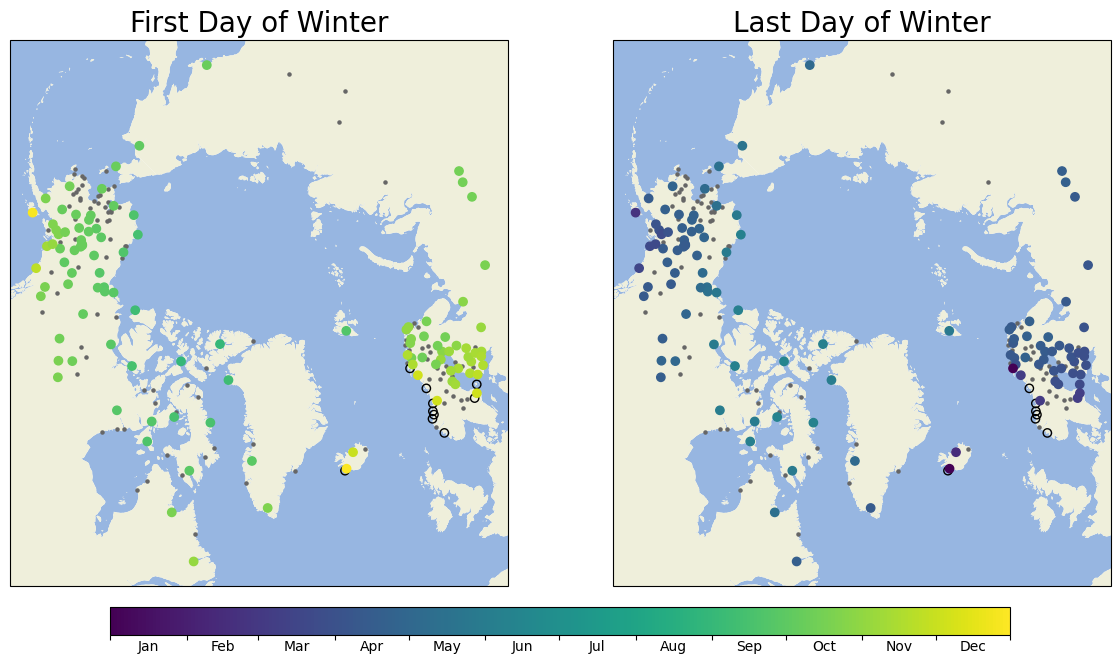

In [9]:
norm = Normalize(vmin=1, vmax=366)
cmap = "viridis"
no_winter_color = "0.0"
other_station_markersize = 20
panel_font_size = 20

fig = plt.figure(figsize=(15,7))

# Plot map of first day of winter
ax1 = fig.add_subplot(121, projection=map_projection)

other_station.to_crs(3413).plot(ax=ax1, markersize=other_station_markersize, marker='.', color='0.4')
# Stations with first_day >= 365 have average t2m above zero
# These are plotted as empty circles
lt_station[lt_station.first_day >= 365].to_crs(3413).plot(ax=ax1, 
                                                          edgecolor=no_winter_color,
                                                          facecolor='none')
# Stations with first_day < 365 have at least one day with average t2m below zero
lt_station[lt_station.first_day < 365].to_crs(3413).plot(column="first_day", 
                                                         ax=ax1, norm=norm, cmap=cmap)
ax1.set_title("First Day of Winter", fontsize=panel_font_size)

ax1.add_feature(cfeature.OCEAN)
ax1.add_feature(cfeature.LAND)

# Plot map of last day of winter
ax2 = fig.add_subplot(122, projection=map_projection)

other_station.to_crs(3413).plot(ax=ax2, markersize=other_station_markersize, marker='.', color='0.4')
# Stations with last_day == 1 never have an average t2m below zero
# These are plotted as empty circles
lt_station[lt_station.last_day == 1].to_crs(3413).plot(ax=ax2,
                                                       edgecolor=no_winter_color,
                                                       facecolor='none')
# Stations with last_day > 1 have at least one day of winter
lt_station[lt_station.last_day > 1].to_crs(3413).plot(column="last_day", 
                                                      ax=ax2, norm=norm, cmap=cmap)
ax2.set_title("Last Day of Winter", fontsize=panel_font_size)

ax2.add_feature(cfeature.OCEAN)
ax2.add_feature(cfeature.LAND)

fig.subplots_adjust(wspace=0.01, left=0.1, right=0.9, bottom=0.1)


# Make ticks and labels for colorbar
doy = np.cumsum([1]+[calendar.monthrange(2004, m)[1] for m in range(1,13)])
doy[12] = doy[12]-1  # get last day of year
doy_label = (doy[:-1] + np.roll(doy, -1)[:-1])*0.5

cax = fig.add_axes([0.2, 0.03, 0.6, 0.04])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# # fake up the array of the scalar mappable. Urgh...
sm._A = []
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
cbar.set_ticks(ticks=doy, labels=[], )
cbar.set_ticks(ticks=doy_label, labels=calendar.month_abbr[1:], minor=True)
cax.tick_params(which='minor', length=0)

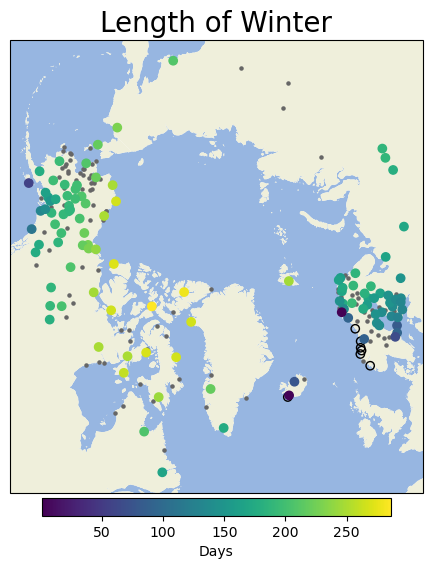

In [10]:
fig = plt.figure(figsize=(15,7))

ax = fig.add_subplot(111, projection=map_projection)

# Convert station metadata GeoDataFrame to 3413 on import
other_station.to_crs(3413).plot(ax=ax, markersize=other_station_markersize, marker='.', color='0.4')
lt_station[lt_station.winter_length == 0].to_crs(3413).plot(ax=ax,
                                                       edgecolor=no_winter_color,
                                                       facecolor='none')
# Stations with last_day > 1 have at least one day of winter
lt_station[lt_station.winter_length > 0].to_crs(3413).plot(
    column="winter_length", 
    ax=ax, legend=True,
    legend_kwds=dict(label="Days",
                     orientation="horizontal",
                     shrink=0.3,
                     pad=0.01),
)

ax.set_title("Length of Winter", fontsize=panel_font_size)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.LAND)


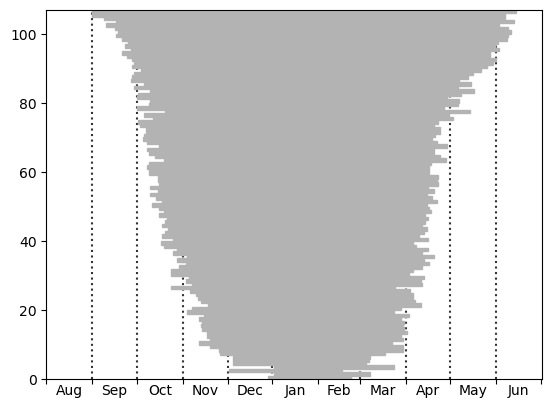

In [11]:
df = lt_station[lt_station.winter_length > 3].sort_values(by="winter_length")

fig, ax = plt.subplots()

ax.set_xlim(213,547)
ax.set_ylim(0,len(df))

for y, (index, data) in enumerate(df.iterrows()):
    # print(data)
    x0 = data.first_day
    x1 = x0 + data.winter_length - 1
    y0 = y
    y1 = y + 1
    xmin, _ = data2axis(x0, y0)
    xmax, _ = data2axis(x1, y0)
    # print(x0, x1, y0, y1, xmin, xmax)
    ax.axhspan(ymin=y0, ymax=y1, xmin=xmin, xmax=xmax, color='0.7')
    # break

# Make x-ticks
date = pd.date_range("2001-08-01", freq="MS", periods=12)
ticks = [doy if doy >= 213 else doy+364 for doy in date.dayofyear]
minor_ticks = (np.roll(ticks, 1)[1:] + ticks[1:])*.5
label = [calendar.month_abbr[m] for m in date.month]
ax.set_xticks(ticks, []);
ax.set_xticks(minor_ticks, label[:-1], minor=True);
ax.tick_params(which="minor", length=0);

# Add vertical lines for month
for t in ticks[1:-1]:
    ax.axvline(t, color="0.2", ls=":", zorder=0)

In [28]:
stid = "PABE"
dfclim = pd.read_csv(f"../data/{stid}.climatology.csv", index_col=0)
dfclim

,t2m,p01i,sog,FZRA,LIQUID,SOLID,UP,p_liquid,p_solid,t2m_min,t2m_10,t2m_25,t2m_50,t2m_75,t2m_90,t2m_max
datetime,,,,,,,,,,,,,,,,
1,-12.772902,0.391667,1.0,0.035714,0.196429,0.785714,0.017857,0.189397,0.721397,-39.790000,-26.739069,-20.410417,-13.262500,-2.850000,-0.125844,2.887500
2,-13.216074,0.230435,1.0,0.000000,0.118644,0.677966,0.016949,0.180032,0.729746,-34.575000,-26.096667,-23.504167,-12.104167,-3.929545,0.444643,2.991667
3,-13.728133,0.872727,1.0,0.000000,0.152542,0.694915,0.050847,0.178411,0.728958,-34.404348,-29.107500,-22.158333,-13.220833,-3.859524,0.305833,2.890476
4,-13.617073,0.823810,1.0,0.019608,0.176471,0.725490,0.000000,0.170508,0.719524,-35.587500,-29.297424,-21.232337,-13.087500,-3.711553,-0.329167,3.961905
5,-13.637809,0.152381,1.0,0.083333,0.229167,0.770833,0.020833,0.177124,0.713127,-34.740000,-28.060000,-22.675000,-13.337500,-3.243750,-0.218116,4.737500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,-12.692141,0.952381,1.0,0.040816,0.163265,0.816327,0.061224,0.163438,0.762720,-36.025000,-27.070833,-20.283333,-13.550000,-2.520833,0.065833,3.177273
363,-13.696823,1.060000,1.0,0.035714,0.232143,0.660714,0.017857,0.173524,0.762476,-34.404167,-28.243333,-21.850000,-14.245833,-3.958333,0.834167,2.854167
364,-13.443692,0.884211,1.0,0.033898,0.203390,0.762712,0.050847,0.184540,0.727175,-33.287500,-29.578750,-21.732917,-12.764583,-4.174049,-0.539333,4.100000


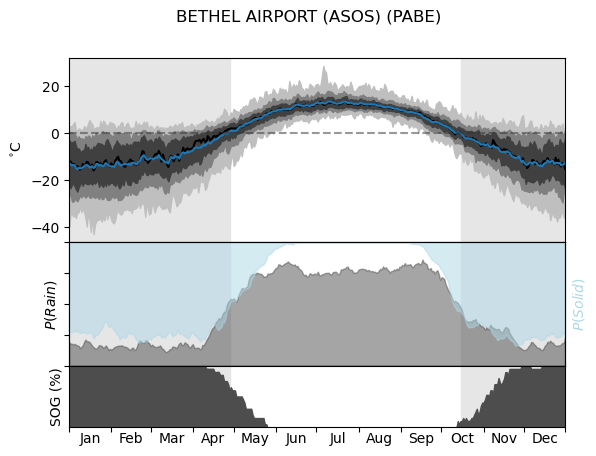

In [29]:
fig = plot_climatology(dfclim, title=f"{station.loc[stid].station_name} ({stid})")
fig.savefig(f"../images/{stid}.climatology.png")

In [37]:
def likelihood_winter_pliquid(df):
    """Returns the likelihood of liquid precipitation
    mask by winter season"""
    
    last_day = df.t2m[df.t2m > 0.].index[0]
    first_day = df.t2m[df.t2m > 0.].index[-1]
    pliquid = df.p_liquid.to_numpy()
    pliquid[last_day:first_day] = np.nan
    return pliquid

In [85]:
these = lt_station[lt_station.winter_length > 3].sort_values(by="winter_length").index

climatology_path = Path("../data")

data = []
for stid in these:
    fp = climatology_path / f"{stid}.climatology.csv"
    dfclim = pd.read_csv(fp, index_col=0)
    data.append(likelihood_winter_pliquid(dfclim))
pliquid = np.roll(np.vstack(data),-212,axis=1)
pliquid = np.where((pliquid > 0) | np.isnan(pliquid), pliquid, -1.)

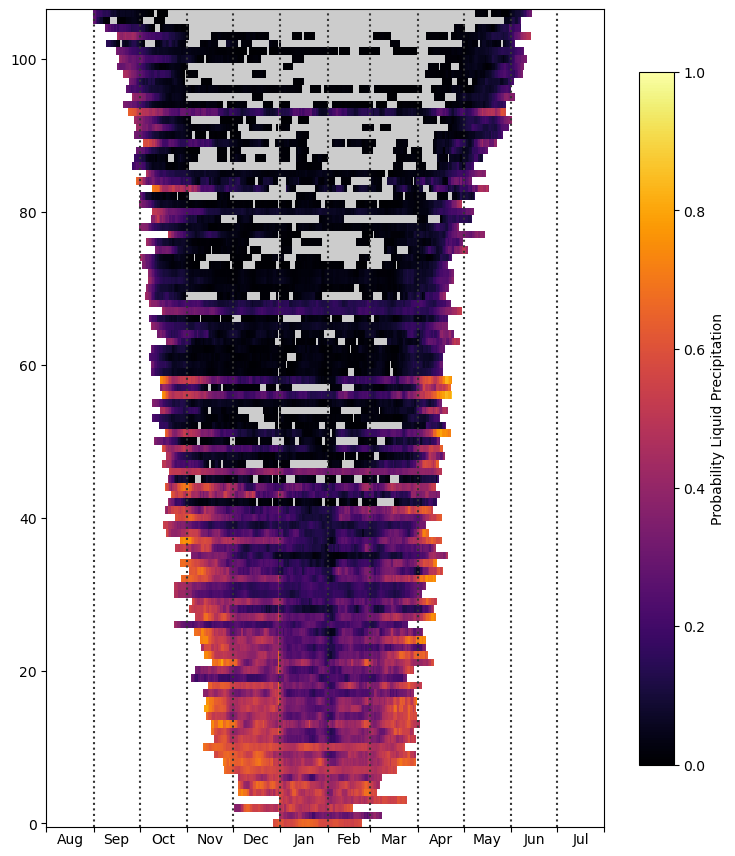

In [127]:
cmap = plt.cm.inferno.with_extremes(under="0.8")
fig, ax = plt.subplots(figsize=(9,12))

ax.set_xlim(1,365)
img = ax.imshow(pliquid, 
          aspect=5, 
          interpolation="none", 
          origin="lower", 
          cmap=cmap,
          norm=Normalize(vmin=0., vmax=1.),
         )

# Make x-ticks
date = pd.date_range("2001-08-01", freq="MS", periods=12)
ticks = np.cumsum([1]+[calendar.monthrange(d.year, d.month)[1] for d in date])
# ticks = [doy for doy in date.dayofyear]
minor_ticks = (np.roll(ticks, 1)[1:] + ticks[1:])*.5
label = [calendar.month_abbr[m] for m in date.month]
ax.set_xticks(ticks, []);
ax.set_xticks(minor_ticks, label, minor=True);
ax.tick_params(which="minor", length=0);

# Add vertical lines for month
for t in ticks[1:-1]:
    ax.axvline(t, color="0.2", ls=":", zorder=0)

fig.colorbar(img, orientation="vertical", shrink=0.75, label="Probability Liquid Precipitation")

fig.savefig("ros_pyramid.png")

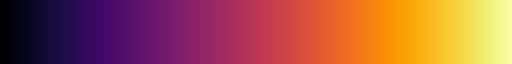

In [95]:
cmap

In [121]:
minor_ticks

array([ 16.5,  47. ,  77.5, 108. , 138.5, 169.5, 199. , 228.5, 259. ,
       289.5, 320. , 350.5])

In [83]:
def make_winter_graphic(df, y=0, height=1., bar_color="0.7", ax=None):
    """Generate a single bar showing climatological
    start and end of winter and likelihood of rain.

    Arguments
    ---------
    df : pandas.DataFrame containing climatology
    y : plotting position on y-axis
    height : height of bar in data units
    ax : matplotlib.axis
    """

    if not ax:
        ax = plt.gca()
        ax.set_xlim(213,547)
        
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    aspect = (xmax-xmin)/(ymax-ymin)
    
    last_day = df.t2m[df.t2m > 0.].index[0]
    first_day = df.t2m[df.t2m > 0.].index[-1]
    length = 365 - first_day + last_day
    x0 = first_day
    x1 = first_day + length
    
    xa0, _ = data2axis(x0, y)
    xa1, _ = data2axis(x1, y0)

    ax.axhspan(ymin=y, ymax=y+height, xmin=xa0, xmax=xa1, color=bar_color)
    # print(xmin, xmax, ymin, ymax, aspect)
    ax.set_aspect(aspect*0.5)
    
    xalt = df.index-xmin
    pliquid = df.p_liquid
    pliquid.loc[last_day:first_day] = pd.NA
    pliquid = np.roll(pliquid, xmin)
    print(pliquid)
    ax.imshow(np.expand_dims(pliquid,axis=0), 
              extent=[xmin, xmax, y, y+height], alpha=1.0, aspect=aspect)

[0.1643797  0.18643484 0.2085213  0.21510025 0.21685464 0.23261278
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan       

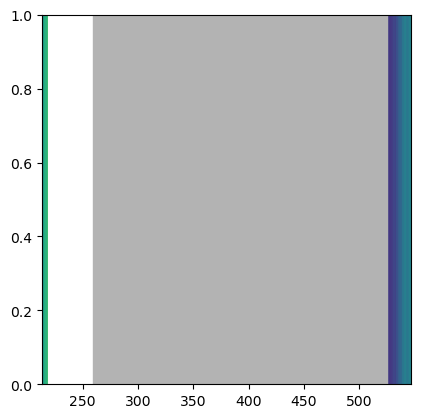

In [84]:
make_winter_graphic(dfclim)

<Axes: xlabel='datetime'>

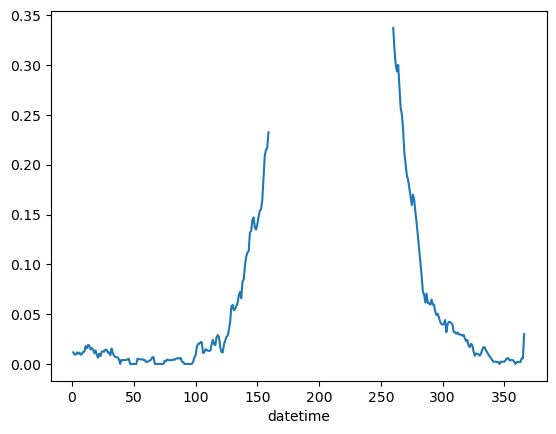

In [76]:
dfclim.p_liquid.where(dfclim.t2m < 0).plot()

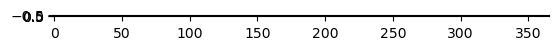

In [128]:
from src.constants import LONG_TERM_STATIONS